Detect infra-slow avalanche (ISA) epochs

In [2]:
%load_ext autoreload
%autoreload 2
import numpy as np
import fmatoolbox as fma
import ISRUtilities as isru
import xarray as xr
import scipy.stats as sps
import pathlib
froot = pathlib.Path().cwd().parent.parent.parent / 'Results/Figures/ISIntervals'
batch_file = '/mnt/hubel-data-103/Pietro/InfraSlowNRPaper/Data/IS_intervals_detection.batch'
do_save = False

In [3]:
def _infraSlowIntervals(session,regs=None,anat=None,when='sleep.*#0',threshold=None,save=False):
    # note: output 'threshold' refers to last phase

    R = fma.regions.regions(session,phases=when,anat_file=anat)
    threshold = threshold[int(R.rat)] # extract thresholds from dict
    regs = R.ids if regs is None else np.asarray(regs)

    # assign variables
    is_reg = np.isin(regs,R.ids)
    isr_dict = {r: [np.zeros((0,2))] if is_reg[i] else [np.full((1,2),np.nan)] for i, r in enumerate(regs)}
    isr_excl_dict = {r: [np.zeros((0,2))] if is_reg[i] else [np.full((1,2),np.nan)] for i, r in enumerate(regs)}
    on_dict = {r: [np.zeros((0,2))] if is_reg[i] else [np.full((1,2),np.nan)] for i, r in enumerate(regs)}
    fraction = np.full(len(regs),np.nan)
    regs = regs[is_reg]
    units = np.array([len(R.units(regs=r)) for r in regs])
    thresh = np.full((len(threshold),len(regs)),np.nan)
    fr_out = []

    # detect ISA per session epoch
    when = R.eventIntervals()
    for k, phase in enumerate(when):

        # avalanches for this epoch
        _, T, _, fr = R.avalanches(regs=regs,when=phase,thresh=threshold[0],window=0.05,step=5,smooth=70,norm=True,return_fr=True)
        fr_out.append(fr)

        for i, r in enumerate(regs):

            # 1. validate number of units
            if units[i] < 15:
                continue

            thresh = np.percentile(fr[:,1:],threshold,axis=0) # (threshold, region), absolute threshold from percentiles
            thresh[1] /= 4 # for min threshold, percentile(fr) / 4
            thresh[2] /= 3 # for max threshold, percentile(fr) / 3
            half_t = phase.mean()

            # 2. detect drift in region firing rate
            t_idx = T[r][:,0] > half_t # t_idx[i] indexes partition to which T[r][i] belongs
            dur = np.diff(T[r]).ravel()
            t1 = dur[~t_idx].sum()
            drift_ratio = dur[t_idx].sum() / t1 if t1 != 0 else np.inf
            drift = np.diff(phase) > 6000 and (np.any(dur > np.diff(phase)*3/10) or drift_ratio < 0.1 or drift_ratio > 10)
            if drift:
                # flag region as invalid
                print(f'drift detected in {R.basename} {r}, phase {k}, drift ratio: {drift_ratio}')
                continue

            # 3. detect ISA
            big = np.diff(T[r],axis=1).ravel() > 15 # 15 s, parameter to explore
            big[-1] = True # always exclude last avalanche to end last ISR epoch
            break_idx = np.where(big)[0]
            # ISR start and stop indexes
            start = np.insert(break_idx+1,0,0)
            stop = np.append(break_idx,len(big))
            valid = start != stop
            start = start[valid]
            stop = stop[valid]
            # putative ISR intervals
            isr = np.column_stack((T[r][start,0], T[r][stop,0])) # from onset of first ON to onset of discarded ON
            on = T[r][~big,:]
            isr_idx = np.cumsum(np.insert(~big[:-1] & big[1:],0,0))
            isr_idx = isr_idx[~big] # isr_idx[i] is idx of putative ISR interval containing i-th ON

            # 4. filter ISR intervals for max and min requirements
            valid = np.full(len(isr),False)
            fr_isr, fisr_idx = fma.general.restrict(fr[:,[0,i+1]],isr,i_ind=True)
            for j in range(len(isr)):
                this_fr = fr_isr[fisr_idx==j,1] # firing rate values in j-th putative ISR interval
                if len(this_fr) > 0:
                    valid[j] = (np.percentile(this_fr,15) < thresh[1,i]) and (np.percentile(this_fr,80) > thresh[2,i])

            # collect intervals for each phase
            isr_dict[r].append(isr[valid,:])
            isr_excl_dict[r].append(isr[~valid,:])
            on_dict[r].append(on[np.isin(isr_idx, np.where(valid)[0]),:])

    for i, r in enumerate(regs):
        # concatenate intervals for each region
        isr_dict[r] = np.concatenate(isr_dict[r],axis=0)
        isr_excl_dict[r] = np.concatenate(isr_excl_dict[r],axis=0)
        on_dict[r] = np.concatenate(on_dict[r],axis=0)
        fraction[i] = np.diff(isr_dict[r],axis=1).sum() / np.diff(when,axis=1).sum()

    if save:
        data1 = {f'slow{r}': isr_dict[r] for r in isr_dict}
        data2 = {f'slowaval{r}': on_dict[r] for r in on_dict}
        np.savez(R.session / 'InfraSlowRhythm' / (R.basename+'.infraslowaval.npz'),**data1,**data2)

    fraction = xr.DataArray(fraction,dims='region',coords={'region': regs, 'rat': int(R.rat), 'base': R.basename})
    threshold = xr.DataArray(thresh,dims=['n','region'],coords={'region': regs, 'rat': int(R.rat)})
    units = xr.DataArray(units,dims='region',coords={'region': regs, 'rat': int(R.rat)})

    return fraction, isr_dict, on_dict, isr_excl_dict, np.concatenate(fr_out), threshold, units

In [4]:
threshold = {3: [20,90,95], 4: [20,97,100], 2: [20,100,100], 11: [20,75,80], 12: [20,98,97], 386: [20,90,95], 392: [20,90,95], 399: [20,90,95], 401: [20,90,95]} # rat -> thresholds

In [4]:
# test on one session
session, args = fma.data.readBatchFile(batch_file)
session, args = session[13], args[13]
if args == []:
    args = [None, None]
print(session)
fraction, isr_dict, on_dict, isr_excl_dict, fr, thresh_data, units = _infraSlowIntervals(session,regs=args[0],anat=args[1],when='sleep.*',threshold=threshold,save=False)

/mnt/hubel-data-139/perceval/Rat003_20231229/Rat003_20231229.xml


['hpc 57 0.0', 'nr 58 0.33787421824567226', 'pfc 56 0.0']


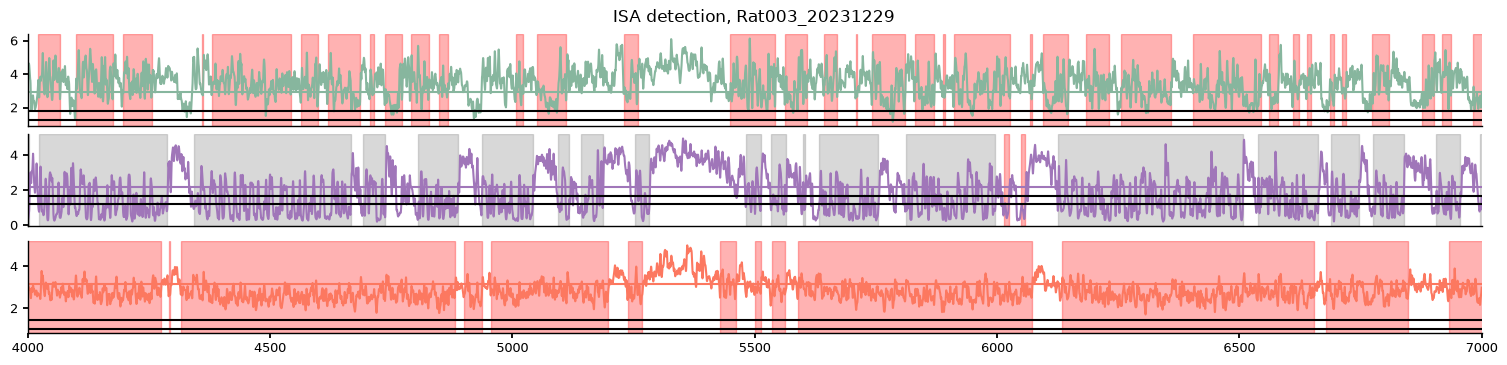

In [8]:
print([f"{fraction['region'][i].item()} {units[i].item()} {f}" for i, f in enumerate(fraction.values)])
start = 4000
stop = start + 3000
fig, ax = fma.plotting.makeFigure(f'ISA detection, {fraction.base.values}',[len(fraction['region']),1],size=[38,len(fraction['region'])*3])
for i, r in enumerate(fraction['region'].values):
    fma.plotting.plotXY(fr[:,[0,1+i]],start,stop,color=isru.paperColors(r),ax=ax[i])
    ax[i].axhline(thresh_data[0].sel(region=r),color=isru.paperColors(r))
    ax[i].axhline(thresh_data[1].sel(region=r),color='k')
    ax[i].axhline(thresh_data[2].sel(region=r),color='k')
    fma.plotting.plotIntervals(isr_dict[r],ax=ax[i])
    fma.plotting.plotIntervals(isr_excl_dict[r],color='r',ax=ax[i])
    ax[i].set_xlim([start,stop])
fma.plotting.setProp(ax[:-1],xticks=[]);

run batch

In [5]:
fraction, isr_dict, on_dict, isr_excl_dict, fr, thresh_data, units = fma.data.runBatch(batch_file,_infraSlowIntervals,kwargs={'when': 'sleep.*','threshold': threshold, 'save': False},parallel=True)
# concatenate sessions
fraction_cat = xr.concat([d for d in fraction if d is not None],dim='rat',join='outer') # (session, region, threshold)
# average per animal
fraction_avg = fraction_cat.groupby('rat').mean(dim='rat',skipna=True)
regs = ['nr','th','hpc','lvHPC','rvHPC','ldHPC','rdHPC','pfc','lvmPFC','rvmPFC','ldmPFC','rdmPFC','v1','lAMY','rAMY']


Starting Batch, 2026-07-23 17:40:26.476145 

drift detected in Rat399-20190402 rvHPC, phase 0, drift ratio: 0.5666541096072125
drift detected in Rat401-20190616 lAMY, phase 0, drift ratio: 0.184102203506332
drift detected in Rat012_2025-12-10 pfc, phase 0, drift ratio: 1.6572529981756152
drift detected in Rat012_2025-12-16 pfc, phase 0, drift ratio: 0.0
drift detected in Rat012_2025-12-17 pfc, phase 0, drift ratio: 0.0
drift detected in Rat401-20190616 lAMY, phase 2, drift ratio: inf
drift detected in Rat401-20190616 rAMY, phase 2, drift ratio: inf
drift detected in Rat401-20190616 lvmPFC, phase 2, drift ratio: inf
Error in session /mnt/cortex-data-311/Rat386-20180924/Rat386-20180924.xml (62)
index 0 is out of bounds for axis 1 with size 0
Traceback:
Error in session /mnt/cortex-data-309/Rat392-20181103/Rat392-20181103.xml (69)
index 0 is out of bounds for axis 1 with size 0
Traceback:
Batch completed with 2 errors, 2026-07-23 17:41:09.495800


/tmp/ipykernel_165861/2125823979.py:3: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  fraction_cat = xr.concat([d for d in fraction if d is not None],dim='rat',join='outer') # (session, region, threshold)


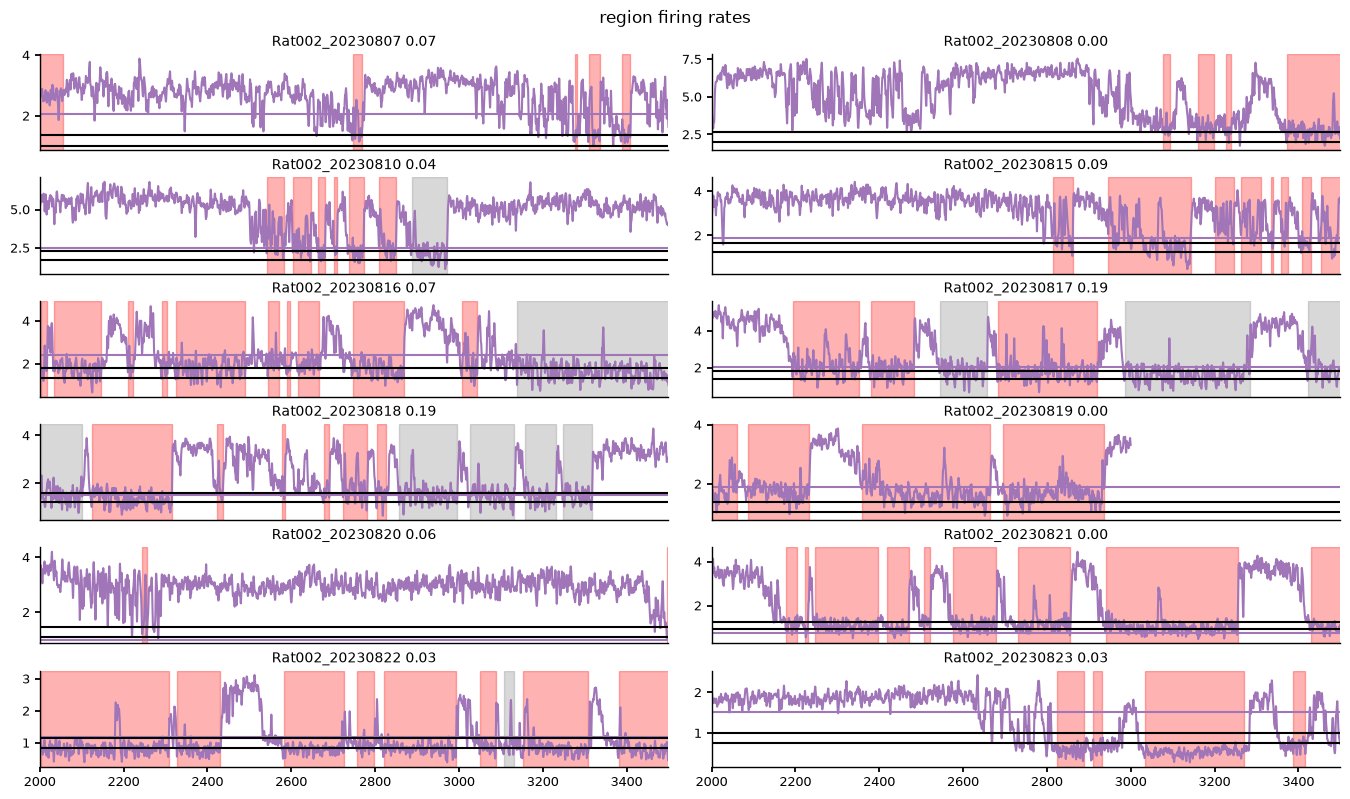

In [26]:
# see NR results
start = np.array([000,000, 2000,2000, 2700,11000, 11000,11000, 1800,3000,2000,2000])
stop = start + 1500
rat = 2
sessions = np.where(fraction_cat['rat']==rat)[0][::]
fig, ax = fma.plotting.makeFigure('region firing rates',[(len(sessions)+1)//2,2],size=[34,3.2*(len(sessions)+1)//2])
for i, s in enumerate(sessions):
        r_ind = int(np.where(fraction[s]['region']=='nr')[0][0])
        a_idx = np.unravel_index(i,ax.shape)
        fma.plotting.plotXY(fr[s][:,[0,1+r_ind]],start[i],stop[i],color=isru.paperColors('nr'),ax=ax[a_idx])
        ax[a_idx].axhline(thresh_data[s][0].sel(region='nr'),color=isru.paperColors('nr'))
        ax[a_idx].axhline(thresh_data[s][1].sel(region='nr'),color='k')
        ax[a_idx].axhline(thresh_data[s][2].sel(region='nr'),color='k')
        fma.plotting.plotIntervals(isr_dict[s]['nr'],ax=ax[a_idx])
        fma.plotting.plotIntervals(isr_excl_dict[s]['nr'],color='r',ax=ax[a_idx])
        ax[a_idx].set_xlim([start[i],stop[i]])
        title = f"{fraction[s]['base'].item()} {fraction[s].sel(region='nr').values:.2f}"
        if 'th' in fraction[s].region: title += f" vs {fraction[s].sel(region='th').values:.2f}"
        ax[a_idx].set_title(title,fontsize=10)
fma.plotting.setProp(ax[:-1,:],xticks=[]);

IndexError: index 0 is out of bounds for axis 0 with size 0

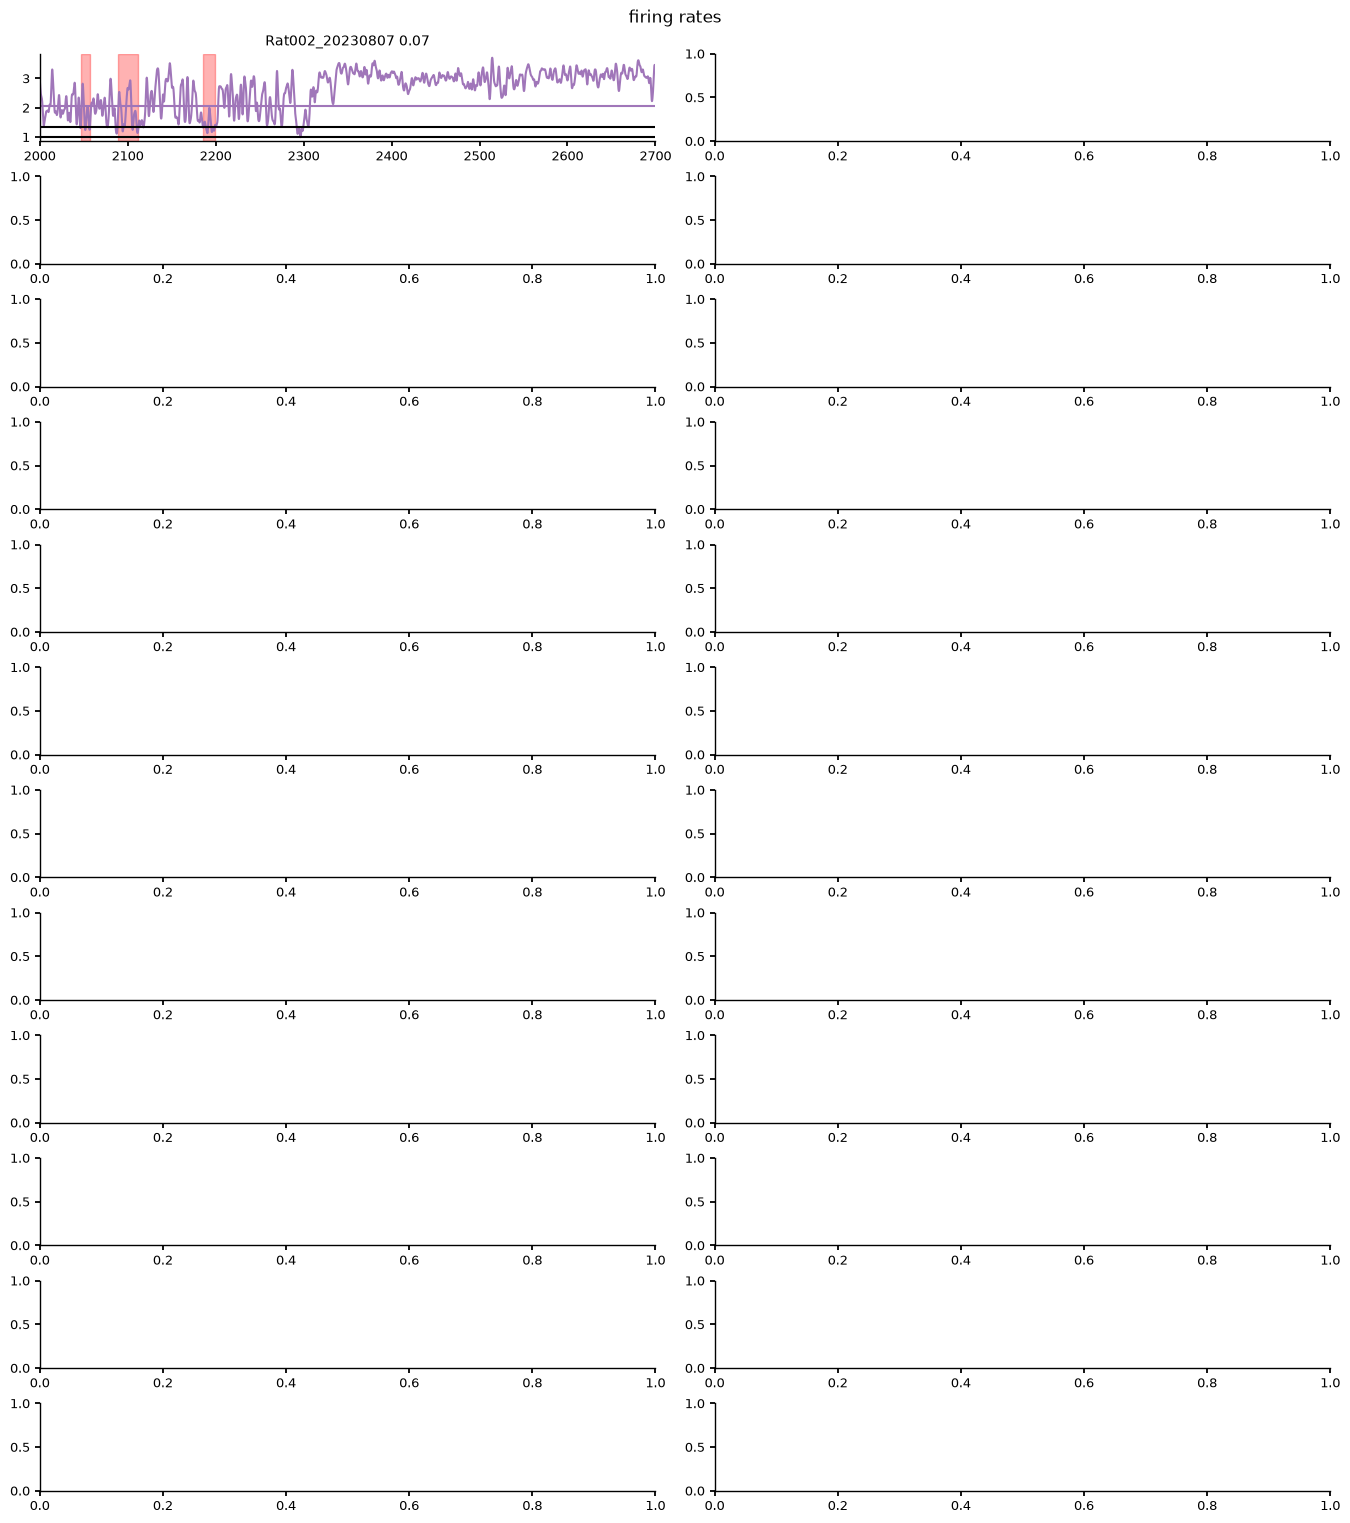

In [27]:
# compare NR and HPC
start = np.array([2000,1500,3000,10000,10000,10000, 2000,2000])
stop = start + 700
rat = 2
sessions = np.where(fraction_cat['rat']==rat)[0][::]
#sessions = [50,52,53,55,56,57]
fig, ax = fma.plotting.makeFigure('firing rates',[len(sessions),2],size=[34,3.2*len(sessions)])
for i, s in enumerate(sessions):
    for k, r in enumerate(['nr','hpc']):
        r_ind = int(np.where(fraction[s]['region']==r)[0][0])
        fma.plotting.plotXY(fr[s][:,[0,1+r_ind]],start[i],stop[i],color=isru.paperColors(r),ax=ax[i,k])
        ax[i,k].axhline(thresh_data[s][0].sel(region=r),color=isru.paperColors(r))
        ax[i,k].axhline(thresh_data[s][1].sel(region=r),color='k')
        ax[i,k].axhline(thresh_data[s][2].sel(region=r),color='k')
        fma.plotting.plotIntervals(isr_dict[s][r],ax=ax[i,k])
        fma.plotting.plotIntervals(isr_excl_dict[s][r],color='r',ax=ax[i,k])
        ax[i,k].set_xlim([start[i],stop[i]]), ax[i,k].set_title(f"{fraction[s]['base'].item()} {fraction[s].sel(region=r).values:.2f}",fontsize=10)
fma.plotting.setProp(ax[:-1,:],xticks=[]);

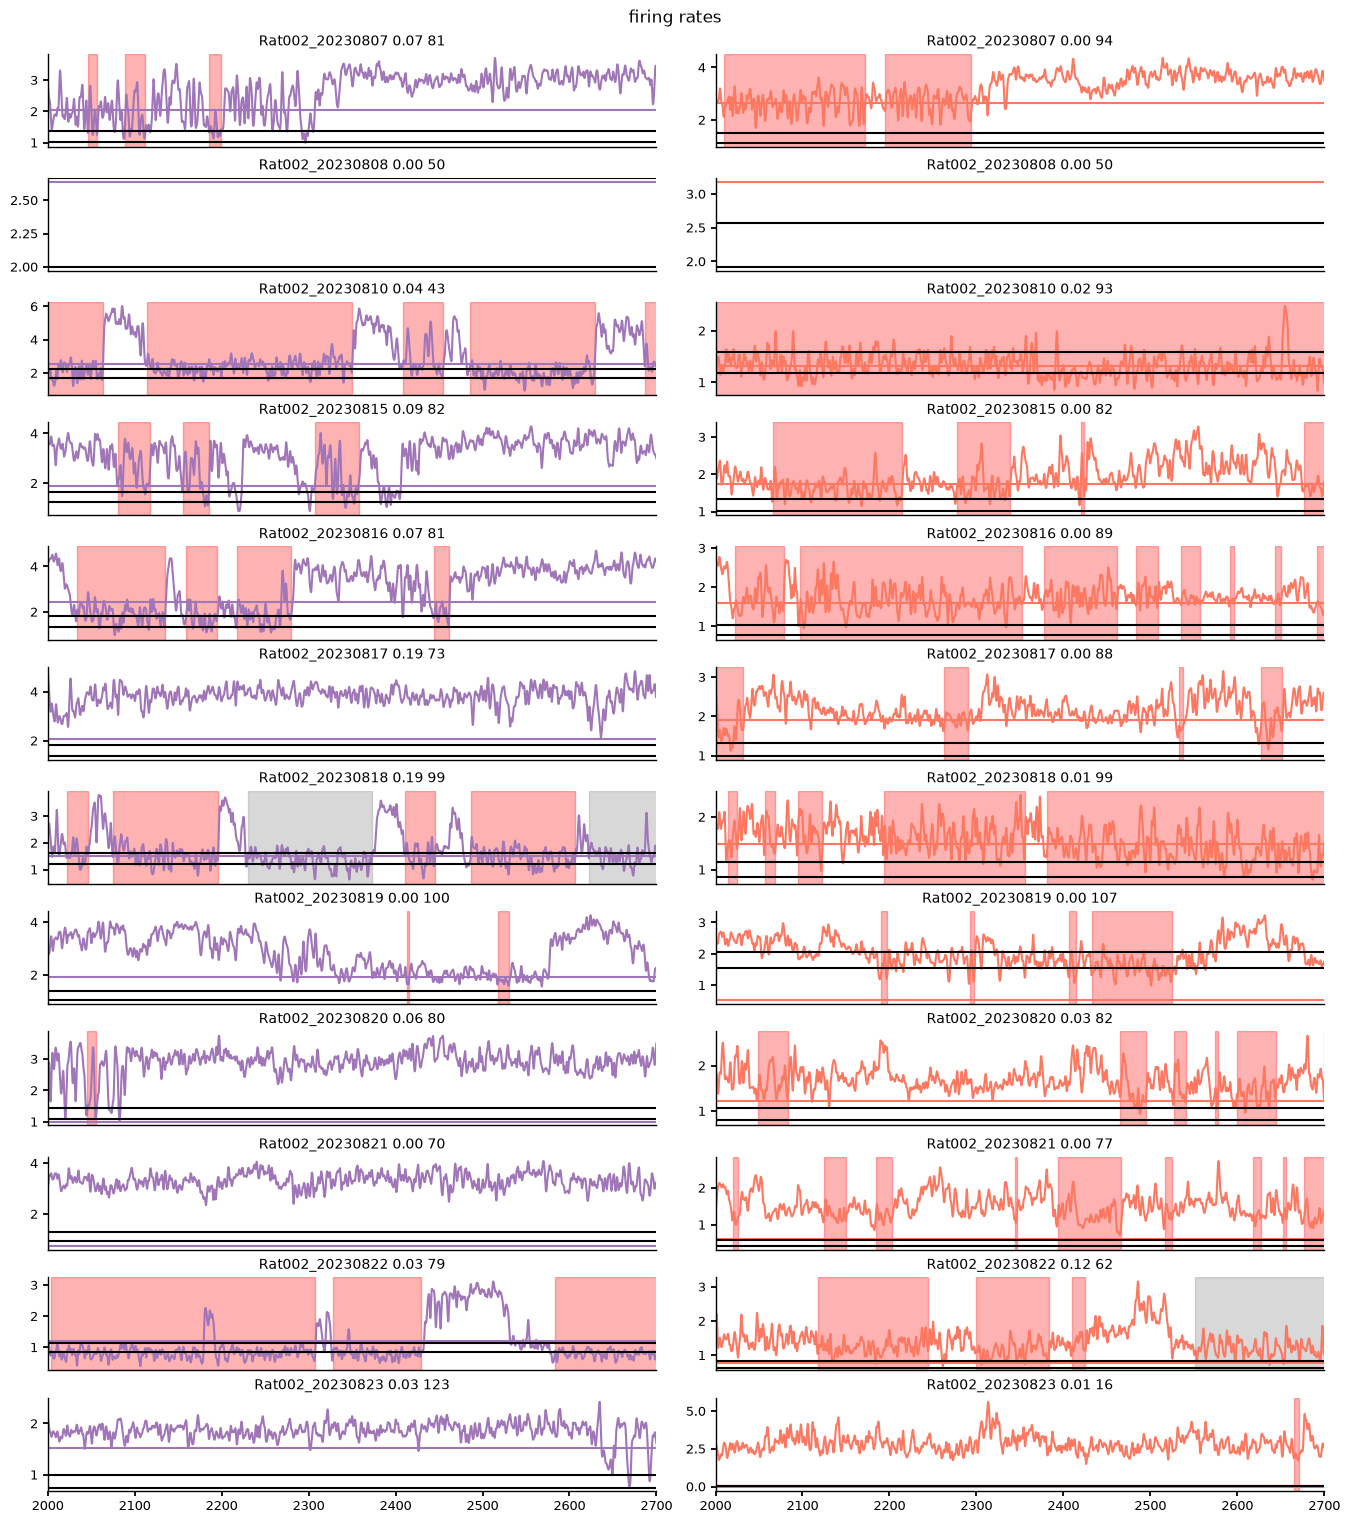

In [30]:
# compare NR and PFC
start = np.array([2000,6000,4000,4000,8000,000,2000,2000,2000,2000,2000,2000])
stop = start + 700
rat = 2
sessions = np.where(fraction_cat['rat']==rat)[0][::]
#sessions = [52,53,54,55,56,57]
fig, ax = fma.plotting.makeFigure('firing rates',[len(sessions),2],size=[34,3.2*len(sessions)])
for i, s in enumerate(sessions):
    for k, r in enumerate(['nr','pfc']):
        r_ind = int(np.where(fraction[s]['region']==r)[0][0])
        fma.plotting.plotXY(fr[s][:,[0,1+r_ind]],start[i],stop[i],color=isru.paperColors(r),ax=ax[i,k])
        ax[i,k].axhline(thresh_data[s][0].sel(region=r),color=isru.paperColors(r))
        ax[i,k].axhline(thresh_data[s][1].sel(region=r),color='k')
        ax[i,k].axhline(thresh_data[s][2].sel(region=r),color='k')
        fma.plotting.plotIntervals(isr_dict[s][r],ax=ax[i,k])
        fma.plotting.plotIntervals(isr_excl_dict[s][r],color='r',ax=ax[i,k])
        ax[i,k].set_xlim([start[i],stop[i]]), ax[i,k].set_title(f"{fraction[s]['base'].item()} {fraction[s].sel(region=r).values:.2f} {units[s].sel(region=r).values}",fontsize=10)
fma.plotting.setProp(ax[:-1,:],xticks=[]);

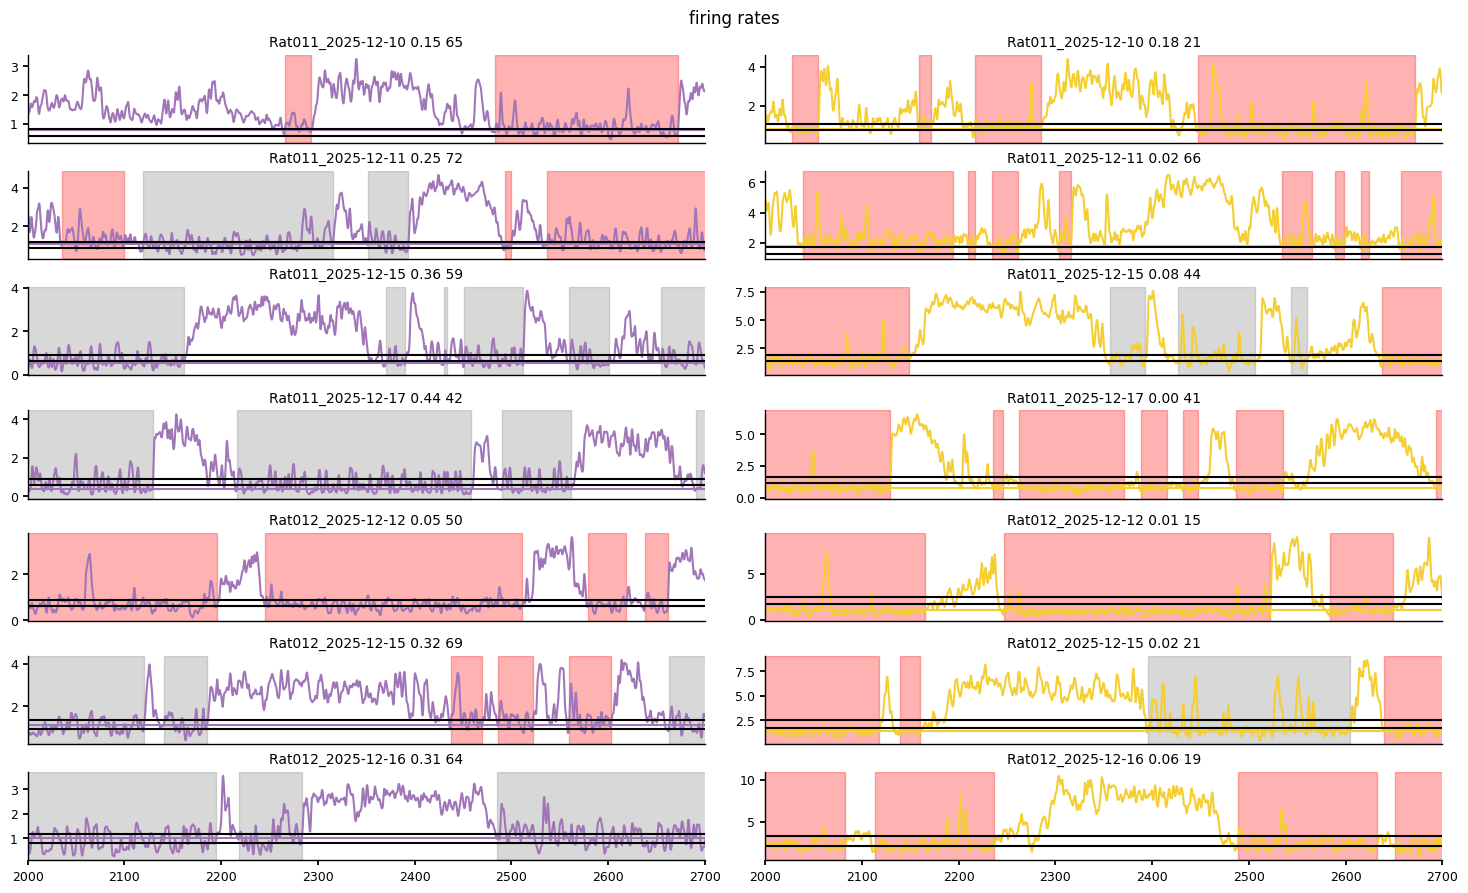

In [16]:
# compare NR and TH
start = np.array([2000,4000,4000,4000,4000,4000,2000,2000])
stop = start + 700
sessions = [44,45,47,49,54,55,56]
fig, ax = fma.plotting.makeFigure('firing rates',[len(sessions),2],size=[37,3.2*len(sessions)])
for i, s in enumerate(sessions):
    for k, r in enumerate(['nr','th']):
        r_ind = int(np.where(fraction[s]['region']==r)[0][0])
        fma.plotting.plotXY(fr[s][:,[0,1+r_ind]],start[i],stop[i],color=isru.paperColors(r),ax=ax[i,k])
        ax[i,k].axhline(thresh_data[s][0].sel(region=r),color=isru.paperColors(r))
        ax[i,k].axhline(thresh_data[s][1].sel(region=r),color='k')
        ax[i,k].axhline(thresh_data[s][2].sel(region=r),color='k')
        fma.plotting.plotIntervals(isr_dict[s][r],ax=ax[i,k])
        fma.plotting.plotIntervals(isr_excl_dict[s][r],color='r',ax=ax[i,k])
        ax[i,k].set_xlim([start[i],stop[i]]), ax[i,k].set_title(f"{fraction[s]['base'].item()} {fraction[s].sel(region=r).values:.2f} {units[s].sel(region=r).values}",fontsize=10)
fma.plotting.setProp(ax[:-1,:],xticks=[]);
do_save and fma.plotting.saveFigure(fig,froot / 'Examples/nr_th_detection',['png','svg'])

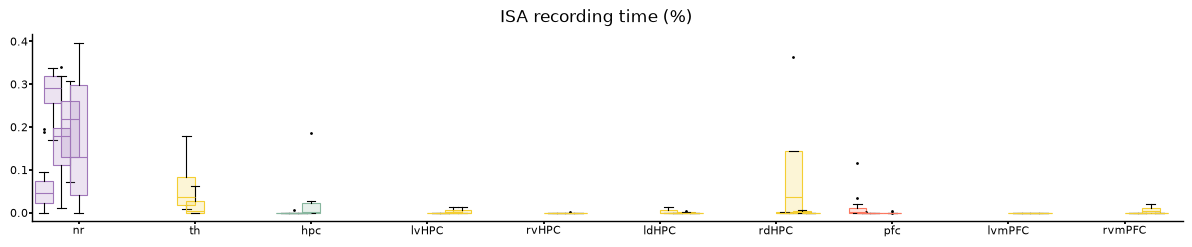

In [6]:
fig, ax = fma.plotting.makeFigure('ISA recording time (%)',size=[30,6])
n_rat = len(np.unique(fraction_cat['rat']))
x = np.linspace(-0.3,0.3,n_rat)
for i, r in enumerate(regs):
    fma.plotting.boxPlot([g for _, g in fraction_cat.sel(region=r).groupby('rat')],x=x+i,color=isru.paperColors(r),ax=ax[0])
ax[0].set_xticks(np.arange(len(regs)),regs); ax[0].set_xlim([-0.4,n_rat+0.5]);

/home/pietro/uvEnvs/fmat_edit_12/lib/python3.12/site-packages/scipy/stats/_wilcoxon.py:192: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


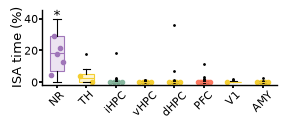

In [10]:
fig, ax = fma.plotting.makeFigure(size=[7,3])

# group data by region, fusing homotopic regions
data = {str(r): g for r, g in fraction_cat.groupby('region')}
data['amy'] = xr.concat((data['lAMY'].assign_coords(region=['amy']),data['rAMY'].assign_coords(region=['amy'])),dim='rat')
data['PFC'] = xr.concat((data['pfc'].assign_coords(region=['pfc']),data['lvmPFC'].assign_coords(region=['pfc']),data['rvmPFC'].assign_coords(region=['pfc']),
                          data['ldmPFC'].assign_coords(region=['pfc']),data['rdmPFC'].assign_coords(region=['pfc'])),dim='rat')
data['vhpc'] = xr.concat((data['lvHPC'].assign_coords(region=['vhpc']),data['rvHPC'].assign_coords(region=['vhpc'])),dim='rat')
data['dhpc'] = xr.concat((data['ldHPC'].assign_coords(region=['dhpc']),data['rdHPC'].assign_coords(region=['dhpc'])),dim='rat')
regs = ['nr','th','hpc','vhpc','dhpc','PFC','v1','amy']
labels = ['NR','TH','iHPC','vHPC','dHPC','PFC','V1','AMY']

# plot data
fma.plotting.boxPlot([data[r]*100 for r in regs],color=isru.paperColors(regs),ax=ax[0])
medians = {}
for i, r in enumerate(regs):
    medians[r] = data[r].groupby('rat').median('rat').values * 100
    medians[r] = medians[r][~np.isnan(medians[r])]
    ax[0].scatter(np.linspace(-0.2,0.2,len(medians[r]))+i+1,medians[r],c=isru.paperColors(r),marker='.')
ax[0].set_xticks(np.arange(1,len(regs)+1),labels,rotation=45)
ax[0].set(ylabel='ISA time (%)')

# test distributions against zero
p_val = []
for r in regs:
    if len(medians[r]) > 1:
        stat, p = sps.wilcoxon(medians[r],alternative='greater')
        p_val.append(p)
    else:
        p_val.append(np.nan)
# FWER correction
#reject, pvals_fdr, _, _ = smsm.multipletests(p_val,alpha=0.05,method='fdr_bh')
reject = np.array(p_val) < 0.05

# plot significance
y_lim = ax[0].get_ylim()
for i, r in enumerate(reject):
    if r:
        ax[0].text(i+1,y_lim[1],'*',ha='center',va='center',color='k',size=None)
ax[0].set_ylim([y_lim[0],y_lim[1]*1.1])
do_save and fma.plotting.saveFigure(fig,froot / 'detection',['png','svg'])

Are first blinky sessions maybe not in NR?? MUST CHECKKK